2 broad types of derivatives we can take:


1.   Symbolic (real/exact derivative of a function) – similar to what one does in a traditional calculus course
2.   Numerical derivative using [Finite Difference](https://en.wikipedia.org/wiki/Finite_difference) method 



# Symbolic

In [6]:
import sympy as sym

x = sym.Symbol('x')

def print_derivative(f_x):
  print('derivative of %s = %s' % (f_x, sym.diff(f_x)))
  
print_derivative(x**2)
print_derivative(sym.log(x**3))
print_derivative(sym.sin(x))

derivative of x**2 = 2*x
derivative of log(x**3) = 3/x
derivative of sin(x) = cos(x)


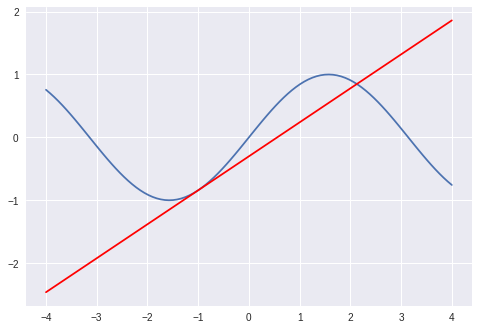

In [20]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 100)
y = np.sin(x)
plt.plot(x, y);

at_x = -1.
d_x = np.cos(at_x)
intercept = np.sin(at_x) - d_x*at_x
plt.plot(x, d_x*x + intercept,'r');

# Numerical

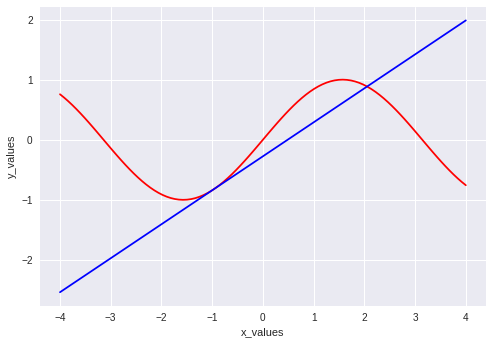

0.5653956078178671


In [22]:
def compute_and_plot_derivative(x_values, y_values, at_x):
  upper = np.argmax(x_values > at_x)
  lower = upper-1 if upper > 0 else 0
  
  d_x = (y_values[upper]-y_values[lower])/(x_values[upper]-x_values[lower])
  intercept = y_values[upper] - d_x*x_values[upper]

  plt.plot(x_values, y_values, 'r')
  plt.ylabel("y_values")
  plt.xlabel("x_values")  
  plt.plot(x_values, d_x*x_values + intercept, 'b')
  plt.show()
  
  return d_x
  
  
d_x = compute_and_plot_derivative(x, y, -1.)
print(d_x)

# Visualizing

In [27]:
from matplotlib import animation, rc
from IPython.display import HTML

def compute_and_animate_derivative(x_values, y_values):  
  fig, ax = plt.subplots()
  plt.close()

  ax.set_xlim((-4, 4))
  ax.set_ylim((-2, 2))

  line1, = ax.plot([], [], lw=2)
  line2, = ax.plot([], [], lw=2)  

  def init():
      line1.set_data(x_values, y_values)      
      return (line1,)

  def animate(i):
    at_x = x_values[i]
    upper = np.argmax(x_values > at_x)
    lower = upper-1 if upper > 0 else 0
    d_x = (y_values[upper]-y_values[lower])/(x_values[upper]-x_values[lower])
    intercept = y_values[upper] - d_x*x_values[upper]
    line2.set_data(x_values, d_x*x_values + intercept)
    return (line2,)

  anim = animation.FuncAnimation(fig, animate, init_func=init, 
                                 frames=99, interval=100, blit=True) 
  rc('animation', html='jshtml')
  anim
  
  return anim

compute_and_animate_derivative(x, y)